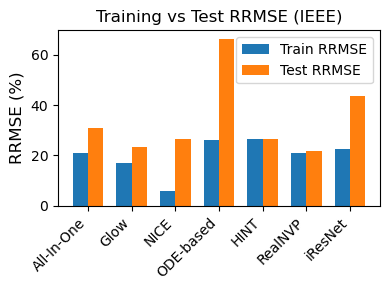

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ["All-In-One", "Glow", "NICE", "ODE-based", "HINT", "RealNVP", "iResNet"]
train = [20.79, 16.85, 5.81, 26.08, 26.64, 20.93, 22.73]
test =  [31.02, 23.38, 26.34, 66.36, 26.49, 21.66, 43.47]

x = np.arange(len(models))
width = 0.35

# Plot
plt.figure(figsize=(4,3))
plt.bar(x - width/2, train, width, label='Train RRMSE')
plt.bar(x + width/2, test, width, label='Test RRMSE')

# Larger labels
plt.xticks(x, models, rotation=45, ha='right', fontsize=10)
plt.ylabel("RRMSE (%)", fontsize=12)
plt.title("Training vs Test RRMSE (IEEE)", fontsize=12)
plt.legend(fontsize=10)

plt.tight_layout()

# Save as PDF
plt.savefig("RRMSE_IEEE.pdf", bbox_inches='tight')

plt.show()

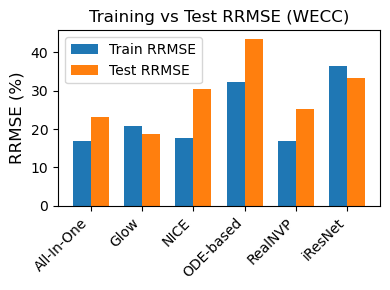

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Daten (WECC)
models = ["All-In-One", "Glow", "NICE", "ODE-based", "RealNVP", "iResNet"]
train = [16.77, 20.84, 17.76, 32.36, 16.96, 36.41]
test  = [23.28, 18.79, 30.35, 43.59, 25.30, 33.34]

x = np.arange(len(models))
width = 0.35

# Plot
plt.figure(figsize=(4, 3))
plt.bar(x - width/2, train, width, label='Train RRMSE')
plt.bar(x + width/2, test, width, label='Test RRMSE')

# Achsenbeschriftung & Layout
plt.xticks(x, models, rotation=45, ha='right', fontsize=10)
plt.ylabel("RRMSE (%)", fontsize=12)
plt.title("Training vs Test RRMSE (WECC)", fontsize=12)
plt.legend(fontsize=10)

plt.tight_layout()

# Save PDF
plt.savefig("RRMSE_WECC.pdf", bbox_inches='tight')

plt.show()


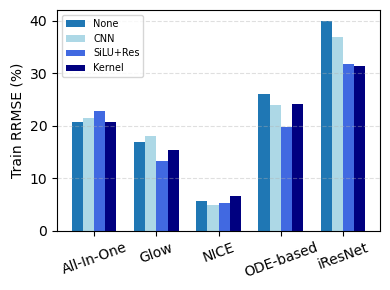

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# DATA
extensions = ["None", "CNN", "SiLU+Res", "Kernel"]
models = ["All-In-One", "Glow", "NICE", "ODE-based", "iResNet"]

train_rrmse = np.array([
    [20.79, 21.47, 22.81, 20.64],
    [16.85, 18.10, 13.31, 15.29],
    [5.59, 4.88, 5.25, 6.67],
    [26.08, 23.93, 19.70, 24.14],
    [40.02, 36.97, 31.68, 31.36],
])

extension_colors = {
    "None": "#1f77b4",
    "CNN": "lightblue",
    "SiLU+Res": "royalblue",
    "Kernel": "navy",
}

x = np.arange(len(models))
bar_width = 0.18

# PLOT — TRAIN RRMSE (FIGSIZE 4×3)
fig, ax = plt.subplots(figsize=(4, 3))

for ext_idx, ext in enumerate(extensions):
    offsets = x + bar_width * (ext_idx - 1.5)
    ax.bar(
        offsets,
        train_rrmse[:, ext_idx],
        width=bar_width,
        color=extension_colors[ext],
        label=ext
    )

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20)
ax.set_ylabel("Train RRMSE (%)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(fontsize=7)

plt.savefig("Hybrid_RRMSE_IEEE_Train.pdf", bbox_inches='tight')
fig.tight_layout()
plt.show()




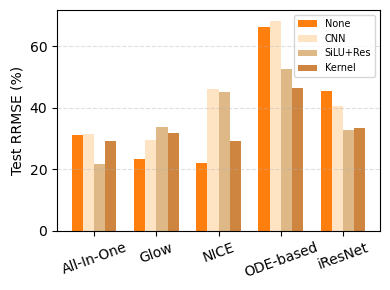

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# DATA
extensions = ["None", "CNN", "SiLU+Res", "Kernel"]
models = ["All-In-One", "Glow", "NICE", "ODE-based", "iResNet"]

test_rrmse = np.array([
    [31.02, 31.41, 21.63, 29.13],
    [23.38, 29.48, 33.66, 31.82],
    [22.01, 46.13, 45.12, 29.31],
    [66.36, 68.44, 52.54, 46.42],
    [45.37, 40.49, 32.73, 33.54],
])

extension_colors = {
    "None": "#ff7f0e",
    "CNN": "bisque",
    "SiLU+Res": "burlywood",
    "Kernel": "peru",
}

x = np.arange(len(models))
bar_width = 0.18

# PLOT — TEST RRMSE (FIGSIZE 4×3)
fig, ax = plt.subplots(figsize=(4, 3))

for ext_idx, ext in enumerate(extensions):
    offsets = x + bar_width * (ext_idx - 1.5)
    ax.bar(
        offsets,
        test_rrmse[:, ext_idx],
        width=bar_width,
        color=extension_colors[ext],
        label=ext
    )

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20)
ax.set_ylabel("Test RRMSE (%)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(fontsize=7)

fig.tight_layout()
plt.savefig("Hybrid_RRMSE_IEEE_Test.pdf", bbox_inches='tight')
plt.show()


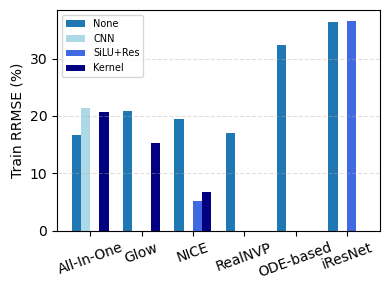

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# DATA
# ----------------------------
extensions = ["None", "CNN", "SiLU+Res", "Kernel"]
models = ["All-In-One", "Glow", "NICE", "RealNVP", "ODE-based", "iResNet"]

train_rrmse = np.array([
    [16.77, 20.84, 19.51, 16.96, 32.36, 36.41],  # No Extension
    [21.47, np.nan,  np.nan,  np.nan, np.nan, np.nan],  # CNN
    [np.nan, np.nan, 5.25,  np.nan, np.nan, 36.65],  # SiLU+Res
    [20.64, 15.29, 6.67, np.nan, np.nan, np.nan],  # Kernel
])

# Fill NaNs with 0 for plotting but we can mask them later
train_rrmse_plot = np.nan_to_num(train_rrmse.T, nan=0.0)

extension_colors = {
    "None": "#1f77b4",
    "CNN": "lightblue",
    "SiLU+Res": "royalblue",
    "Kernel": "navy",
}

x = np.arange(len(models))
bar_width = 0.18

# ----------------------------
# PLOT — TRAIN RRMSE
# ----------------------------
fig, ax = plt.subplots(figsize=(4,3))

for ext_idx, ext in enumerate(extensions):
    offsets = x + bar_width * (ext_idx - 1.5)
    ax.bar(
        offsets,
        train_rrmse_plot[:, ext_idx],
        width=bar_width,
        color=extension_colors[ext],
        label=ext if np.any(train_rrmse_plot[:, ext_idx]>0) else "_nolegend_"
    )

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20)
ax.set_ylabel("Train RRMSE (%)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(fontsize=7)
fig.tight_layout()
plt.show()


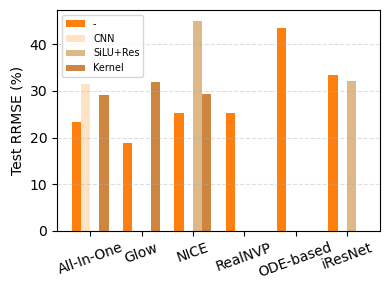

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# DATA
# ----------------------------
extensions = ["None", "CNN", "SiLU+Res", "Kernel"]
models = ["All-In-One", "Glow", "NICE", "RealNVP", "ODE-based", "iResNet"]

test_rrmse = np.array([
    [23.28, 18.79, 25.21, 25.30, 43.59, 33.34],  # No Extension
    [31.41, np.nan,  np.nan,  np.nan, np.nan, np.nan],  # CNN
    [np.nan, np.nan, 45.12,  np.nan, np.nan, 32.12],  # SiLU+Res
    [29.13, 31.82, 29.31, np.nan, np.nan, np.nan],  # Kernel
])

# Fill NaNs with 0 for plotting
test_rrmse_plot = np.nan_to_num(test_rrmse.T, nan=0.0)

extension_colors = {
    "None": "#ff7f0e",       # orange
    "CNN": "bisque",
    "SiLU+Res": "burlywood",
    "Kernel": "peru",
}

x = np.arange(len(models))
bar_width = 0.18

# ----------------------------
# PLOT — TEST RRMSE
# ----------------------------
fig, ax = plt.subplots(figsize=(4,3))

for ext_idx, ext in enumerate(extensions):
    offsets = x + bar_width * (ext_idx - 1.5)
    ax.bar(
        offsets,
        test_rrmse_plot[:, ext_idx],
        width=bar_width,
        color=extension_colors[ext],
        label=ext if np.any(test_rrmse_plot[:, ext_idx]>0) else "_nolegend_"
    )

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20)
ax.set_ylabel("Test RRMSE (%)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(fontsize=7)
fig.tight_layout()
plt.show()
